<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `AnalysisExamples.mlx`
- Fidelity status: `exact`
- Remaining justified differences: The notebook now follows the MATLAB standard-GLM workflow with the canonical `glm_data.mat` dataset and real KS/model-visualization figures; coefficient values and styling still vary modestly because the Python GLM backend and plotting defaults differ from MATLAB.


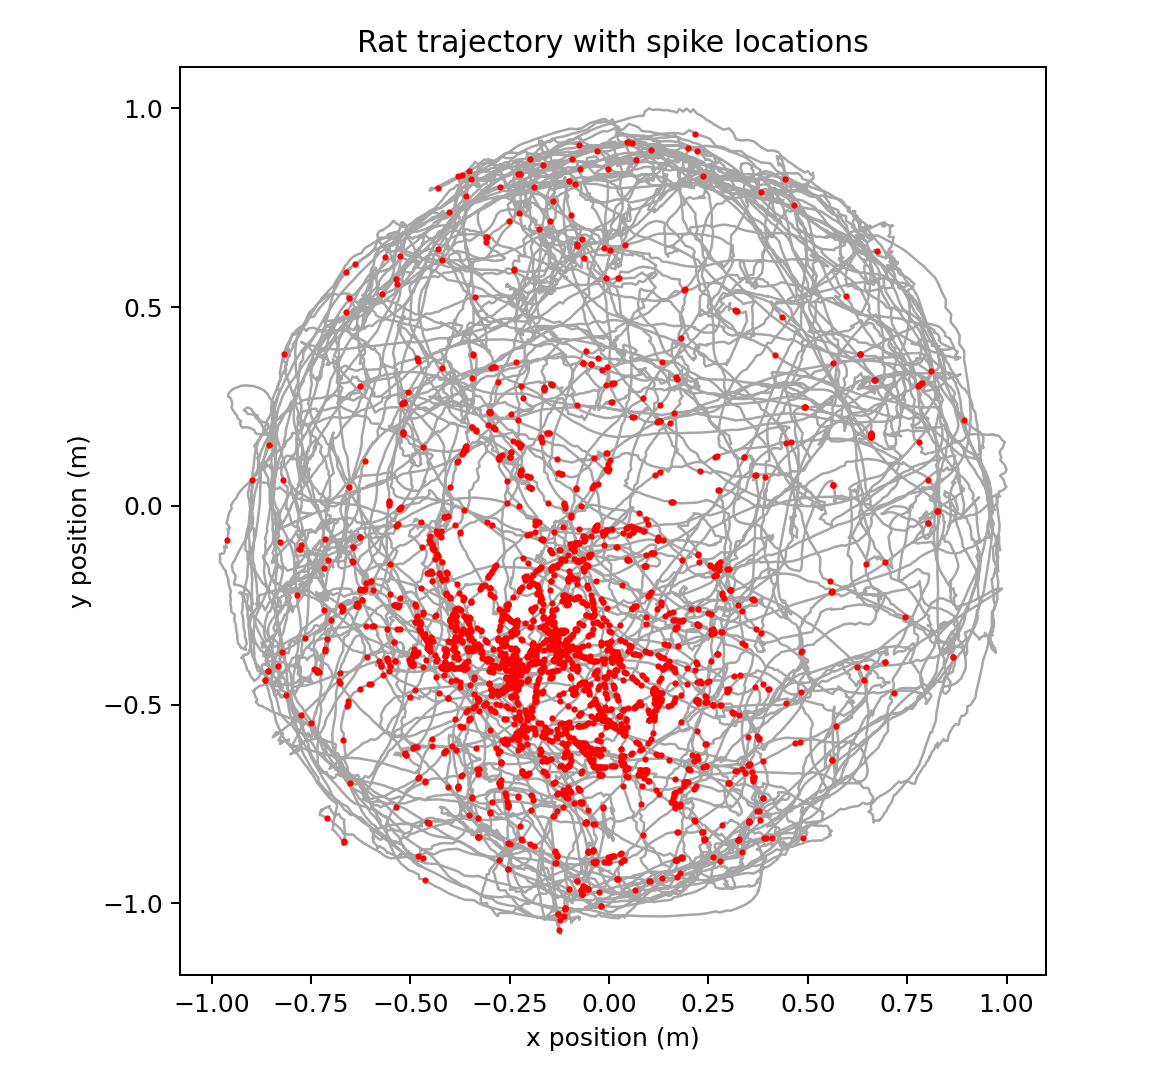

In [1]:
# nSTAT-python notebook example: AnalysisExamples
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat import Analysis, Covariate, nspikeTrain
from nstat.glm import fit_poisson_glm
from nstat.notebook_data import load_glm_data_for_notebook
from nstat.notebook_figures import FigureTracker

GLM_DATA = load_glm_data_for_notebook()
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="AnalysisExamples", output_root=OUTPUT_ROOT, expected_count=4)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _poisson_standard_errors(design_matrix, result):
    x = np.asarray(design_matrix, dtype=float)
    if x.ndim == 1:
        x = x[:, None]
    x_aug = np.column_stack([np.ones(x.shape[0]), x])
    beta = np.concatenate([[result.intercept], np.asarray(result.coefficients, dtype=float)])
    lam = np.exp(np.clip(x_aug @ beta, -20.0, 20.0))
    cov = np.linalg.pinv(x_aug.T @ (lam[:, None] * x_aug))
    return np.sqrt(np.clip(np.diag(cov), 0.0, None))


T = np.asarray(GLM_DATA["T"], dtype=float).reshape(-1)
xN = np.asarray(GLM_DATA["xN"], dtype=float).reshape(-1)
yN = np.asarray(GLM_DATA["yN"], dtype=float).reshape(-1)
spikes_binned = np.asarray(GLM_DATA["spikes_binned"], dtype=float).reshape(-1)
spiketimes = np.asarray(GLM_DATA["spiketimes"], dtype=float).reshape(-1)
x_at_spiketimes = np.asarray(GLM_DATA["x_at_spiketimes"], dtype=float).reshape(-1)
y_at_spiketimes = np.asarray(GLM_DATA["y_at_spiketimes"], dtype=float).reshape(-1)
sample_rate = 1.0 / float(np.median(np.diff(T)))
nst = nspikeTrain(spiketimes, name="1", minTime=float(T[0]), maxTime=float(T[-1]), makePlots=-1)


In [2]:
# SECTION 1: Analysis Examples
plt.close("all")
print({"n_samples": int(T.shape[0]), "n_spikes": int(spiketimes.shape[0]), "sample_rate_hz": round(sample_rate, 3)})


{'n_samples': 41348, 'n_spikes': 2614, 'sample_rate_hz': 30.0}


In [3]:
# SECTION 2: Example 1: Tradition Preliminary Analysis
x_linear = np.column_stack([xN, yN])
x_quadratic_centered = np.column_stack(
    [
        xN,
        yN,
        xN**2 - np.mean(xN**2),
        yN**2 - np.mean(yN**2),
        xN * yN - np.mean(xN * yN),
    ]
)
x_quadratic = np.column_stack([xN, yN, xN**2, yN**2, xN * yN])
linear_fit = fit_poisson_glm(x_linear, spikes_binned)
quadratic_fit = fit_poisson_glm(x_quadratic, spikes_binned)
centered_fit = fit_poisson_glm(x_quadratic_centered, spikes_binned)


Text(0.5, 1.0, 'Rat trajectory with spike locations')

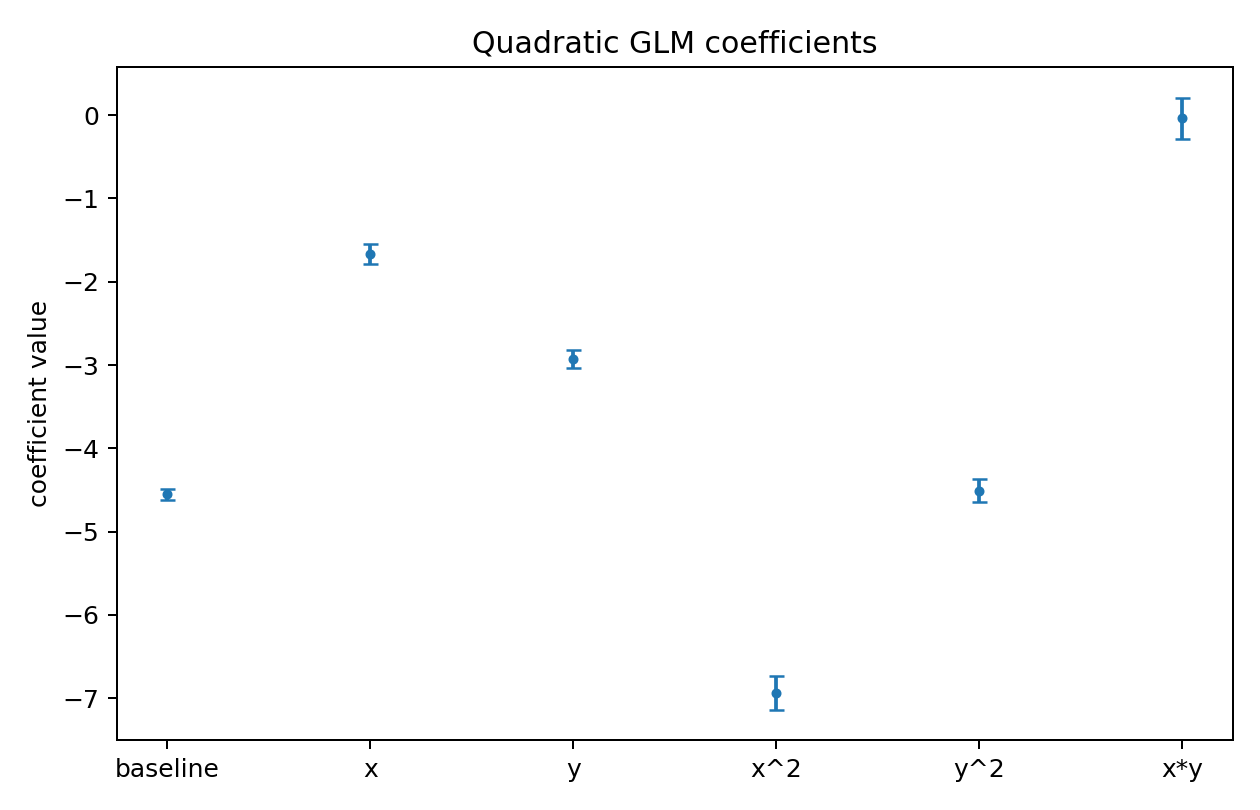

In [4]:
# SECTION 3: visualize the raw data
fig = _prepare_figure("figure; plot(xN,yN,x_at_spiketimes,y_at_spiketimes,'r.')", figsize=(6.5, 6.0))
ax = fig.subplots(1, 1)
ax.plot(xN, yN, color="0.65", linewidth=1.0)
ax.plot(x_at_spiketimes, y_at_spiketimes, "r.", markersize=3.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.set_title("Rat trajectory with spike locations")


Text(0.5, 1.0, 'Quadratic GLM coefficients')

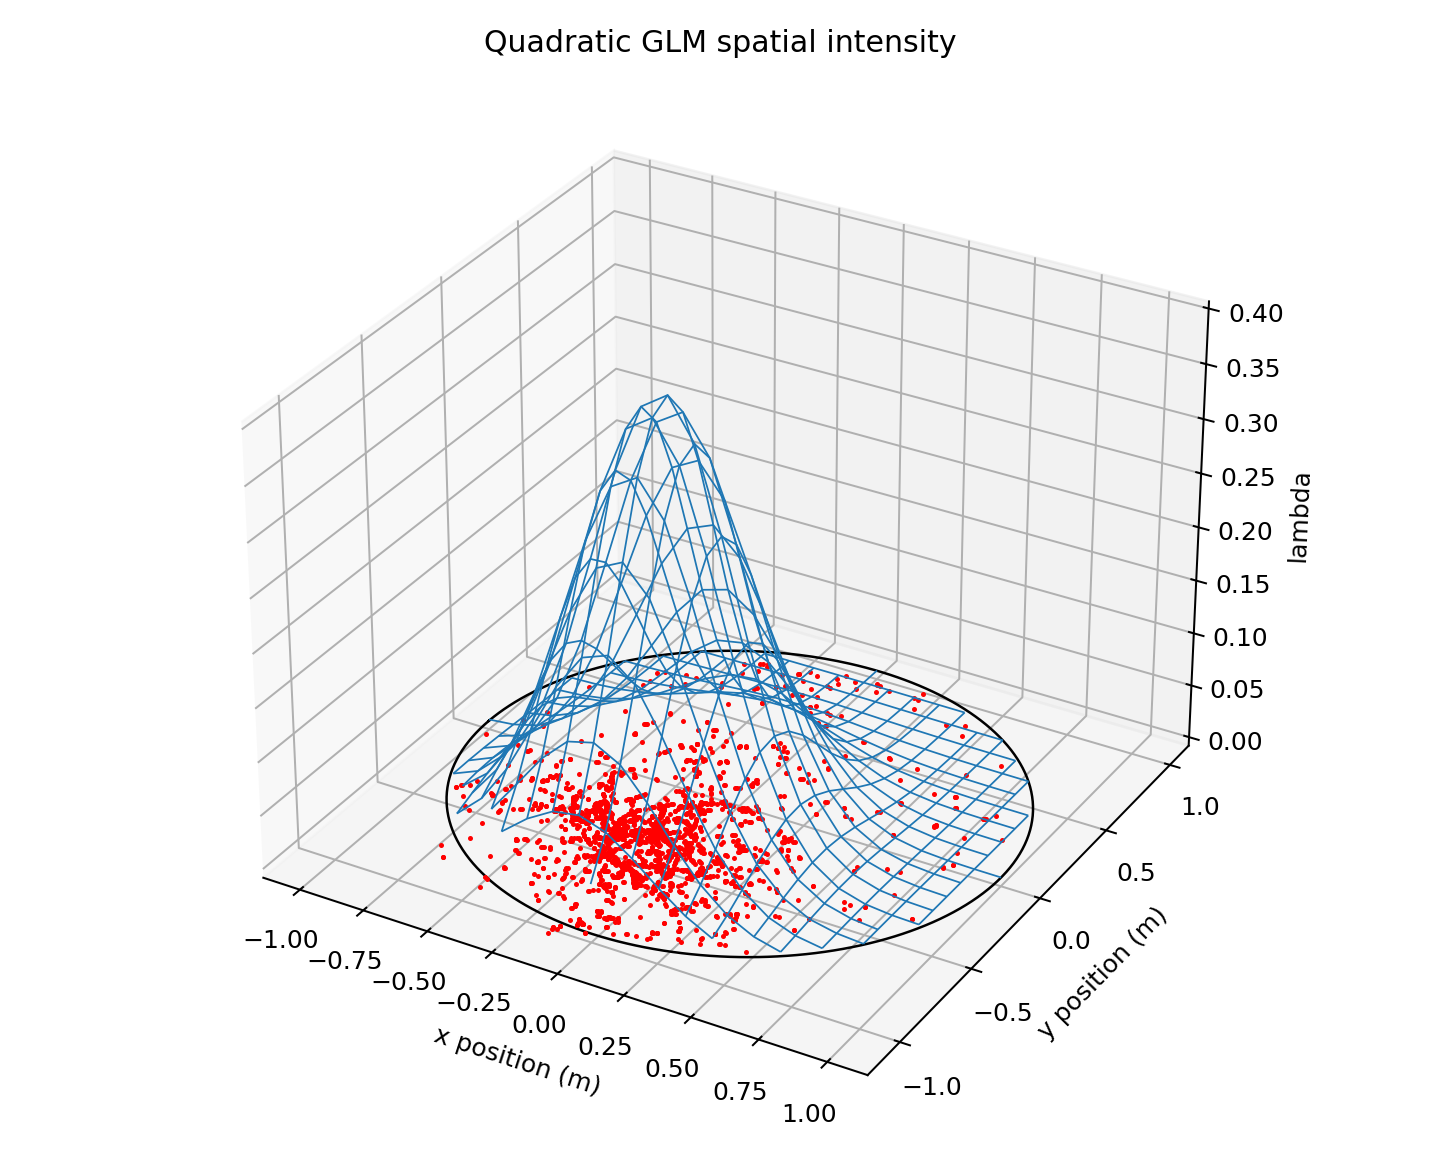

In [5]:
# SECTION 4: fit a GLM model to the x and y positions
fig = _prepare_figure("figure; errorbar(1:length(b), b, stats.se,'.')", figsize=(7.0, 4.5))
ax = fig.subplots(1, 1)
centered_beta = np.concatenate([[centered_fit.intercept], np.asarray(centered_fit.coefficients, dtype=float)])
centered_se = _poisson_standard_errors(x_quadratic_centered, centered_fit)
xpos = np.arange(centered_beta.size)
ax.errorbar(xpos, centered_beta, yerr=centered_se, fmt=".", color="tab:blue", capsize=3)
ax.set_xticks(xpos, ["baseline", "x", "y", "x^2", "y^2", "x*y"])
ax.set_ylabel("coefficient value")
ax.set_title("Quadratic GLM coefficients")


Text(0.5, 0.92, 'Quadratic GLM spatial intensity')

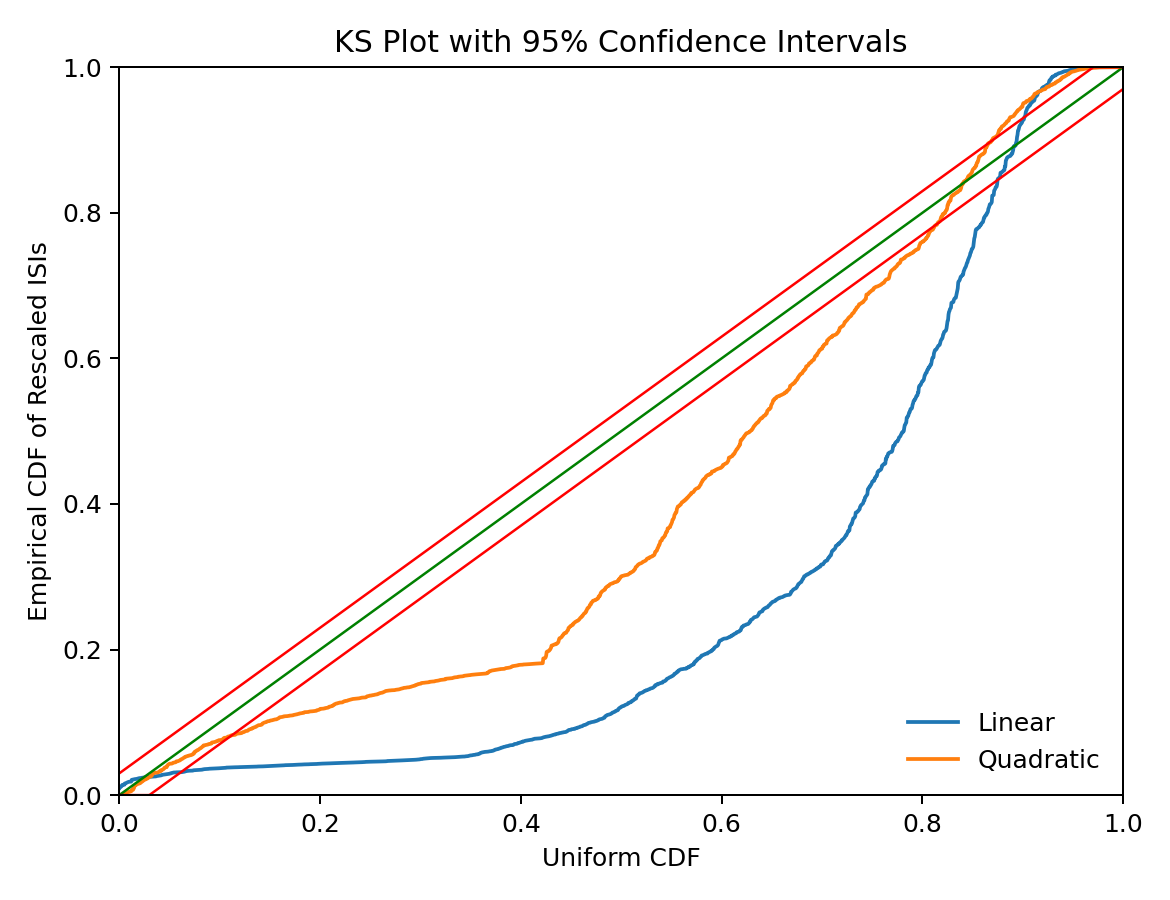

In [6]:
# SECTION 5: visualize your model
fig = _prepare_figure("figure; mesh(x_new,y_new,lambda,'AlphaData',0)", figsize=(8.0, 6.5))
ax = fig.add_subplot(111, projection="3d")
grid = np.arange(-1.0, 1.01, 0.1)
x_new, y_new = np.meshgrid(grid, grid)
X_grid = np.column_stack([x_new.ravel(), y_new.ravel(), x_new.ravel() ** 2, y_new.ravel() ** 2, x_new.ravel() * y_new.ravel()])
lam_grid = quadratic_fit.predict_rate(X_grid).reshape(x_new.shape)
lam_grid = np.where((x_new**2 + y_new**2) <= 1.0, lam_grid, np.nan)
ax.plot_wireframe(x_new, y_new, lam_grid, rstride=1, cstride=1, color="tab:blue", linewidth=0.7)
theta = np.linspace(-np.pi, np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), np.zeros_like(theta), color="k", linewidth=1.0)
ax.plot(x_at_spiketimes, y_at_spiketimes, np.zeros_like(x_at_spiketimes), "r.", markersize=2.0)
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.set_zlabel("lambda")
ax.set_title("Quadratic GLM spatial intensity")


In [7]:
# SECTION 6: Compare a linear model versus a Gaussian GLM model
lambda_linear_hz = linear_fit.predict_rate(x_linear) * sample_rate
lambda_quadratic_hz = quadratic_fit.predict_rate(x_quadratic) * sample_rate
lambda_linear = Covariate(T, lambda_linear_hz, "lambda_linear", "time", "s", "Hz", ["Linear"])
lambda_quadratic = Covariate(T, lambda_quadratic_hz, "lambda_quadratic", "time", "s", "Hz", ["Quadratic"])
print(
    {
        "linear_mean_rate_hz": round(float(np.mean(lambda_linear_hz)), 4),
        "quadratic_mean_rate_hz": round(float(np.mean(lambda_quadratic_hz)), 4),
    }
)


{'linear_mean_rate_hz': 1.8966, 'quadratic_mean_rate_hz': 1.8966}


In [8]:
# SECTION 7: Make the KS Plot
_, _, x_linear_ks, ks_linear, _ = Analysis.computeKSStats(nst, lambda_linear)
_, _, x_quadratic_ks, ks_quadratic, _ = Analysis.computeKSStats(nst, lambda_quadratic)
fig = _prepare_figure("figure; plot(([1:N]-.5)/N, KSSorted, ...)", figsize=(6.5, 5.0))
ax = fig.subplots(1, 1)
x_axis = np.asarray(x_linear_ks, dtype=float).reshape(-1)
ks_linear_arr = np.asarray(ks_linear, dtype=float).reshape(-1)
ks_quadratic_arr = np.asarray(ks_quadratic, dtype=float).reshape(-1)
if x_axis.size:
    ci = 1.36 / np.sqrt(x_axis.size)
    ax.plot(x_axis, ks_linear_arr, color="tab:blue", linewidth=1.5, label="Linear")
    ax.plot(x_axis, ks_quadratic_arr, color="tab:orange", linewidth=1.5, label="Quadratic")
    ax.plot([0.0, 1.0], [0.0, 1.0], "g", linewidth=1.0)
    ax.plot(x_axis, np.clip(x_axis + ci, 0.0, 1.0), "r", linewidth=1.0)
    ax.plot(x_axis, np.clip(x_axis - ci, 0.0, 1.0), "r", linewidth=1.0)
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("Uniform CDF")
ax.set_ylabel("Empirical CDF of Rescaled ISIs")
ax.set_title("KS Plot with 95% Confidence Intervals")
ax.legend(loc="lower right", frameon=False)
__tracker.finalize()
